In [683]:
import ast
import math
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef
from tqdm import tqdm

In [684]:
test_accessions = open("../../../data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()
test_accessions = ['GCF_001277215.2'] #remove

In [685]:
def get_full_cds(reads_dict):
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []
        
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                indices_to_remove += cds_frag_mapping
                
                # Add the new disrupted fragment
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf'])
                
                # Update the dictionary
                reads_dict[read]['cds_coords'] = cds_coords

        # Remove the indices in reverse order to avoid index shifting issues
        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    
    return reads_dict

In [686]:
def load_in_processed_datasets(test_accession, data_type):
    #Load in testset data
    with open(f"../../../data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as testset_dict_file:
        testset_dict = pickle.load(testset_dict_file)

    with open(f"../../../data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as read_names_list_file:
        read_names_list = pickle.load(read_names_list_file)

    with open(f"../../../data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl", "rb") as preds_prodigal_dict_file:
        preds_prodigal = pickle.load(preds_prodigal_dict_file)

    #Load in FGS predictions
    #with open(f"../../../data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
    #    preds_fgs_illumina_5_dict = pickle.load(preds_fgs_dict_file)

    #with open(f"../../../data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
    #    preds_fgs_illumina_10_dict = pickle.load(preds_fgs_dict_file)

    #Load in Model preds
    with open(f"../../../data/processed_data/predictions/processed_predictions/model_shared_crf_preds/{data_type}/full_model_100_genomes_seed_42_trained_final/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_model_8M_shared_nt_dict = pickle.load(model_preds_dict_file)

    with open(f"../../../data/processed_data/predictions/processed_predictions/model_shared_crf_preds/{data_type}/full_model_all_genomes_seed_42_trained_final/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_model_8M_nt_dict = pickle.load(model_preds_dict_file)

        
    return read_names_list, get_full_cds(testset_dict), get_full_cds(preds_prodigal), \
        get_full_cds(preds_prodigal), get_full_cds(preds_prodigal), \
        get_full_cds(preds_model_8M_shared_nt_dict), get_full_cds(preds_model_8M_nt_dict)
    

In [687]:
def calculate_iou(coord1, coord2):
    """
    Calculate Intersection over Union (IoU) for two gene coordinates.
    Each coord (coord1 and coord2, respectively) is a tuple: (cds_start, cds_stop, reading_frame)
    Only compares genes in the same reading frame.
    
    Returns:
      iou: IoU value between 0 and 1, or 0 if different reading frames.
    """

    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    
    #Only compare genes in the same reading frame
    if rf1 != rf2:
        return 0.0
    
    #Calculate intersection
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    #No intersection if start > stop
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    
    #Calculate union
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    
    #Calculate IoU
    iou = intersection_length / union_length if union_length > 0 else 0.0
    
    return iou

In [688]:
def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """
    Find matching genes based on IoU overlap criteria.

    Args:
        predicted_coords (list): List of predicted gene coordinates (tuples).
        actual_coords (list): List of actual gene coordinates (tuples).
        overlap_criteria (float): Minimum IoU required to consider a match.
    
    Returns:
        matched_pairs: list of (pred_idx, actual_idx) pairs that match
        len(matched_paires) = tp_count: number of true positives
    """

    #Initialize
    matched_pairs = []
    used_actual = set()  #Track which actual genes have been matched
    used_predicted = set()  #Track which predicted genes have been matched
    
    #For each predicted gene, find the best matching actual gene
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            #Skip if this actual gene is already matched
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            #Check if this is better than current best and meets criteria
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        #If we found a valid match
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)

    
    return matched_pairs, len(matched_pairs)


In [689]:
def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """
    Calculate sensitivity, precision, and F1-score for given overlap criteria.
    Overlap is based on IoU (Intersection over Union).
    
    Precision (PPV): The ratio of true positives to all predicted genes; TP / (TP + FP)
    Sensitivity (Recall): The ratio of true positives to all actual genes; TP / (TP + FN)
    F1-score: Harmonic mean of precision and sensitivity; 2 * (precision * sensitivity) / (precision + sensitivity)
    
    Args:
        testset_dict: Dictionary containing ground truth CDS coordinates
        model_preds_dict: Dictionary containing predicted CDS coordinates
        all_test_read_names: List of all read names to evaluate
        overlap_criteria: Minimum IoU threshold for considering a match (0.0< to 1.0)
    
    Returns:
        results: Dictionary containing calculated metrics
    """
    
    #Initialize
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    #Iterate through each read
    for read_name in all_test_read_names:

        #Get coordinates for this read; both for test set and model predictions
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        #Count genes for this read
        num_predicted = len(cds_coords_model) #predicted gene fragments
        num_actual = len(cds_coords_testset)  #actual gene fragments

        #Find matching genes based on overlap criteria
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        #Update counts
        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    #Calculate overall metrics
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    #Calculate precision
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    
    #Calculate recall/sensitivity
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    
    #Calculate F1-score (harmonic mean of precision and recall)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    #Store results
    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results

In [690]:
def get_metric_for_models(performance_metric, performance_metrics_genomes_dict):
    """ 
    Get performance metric for all models across genomes in a easy-to-plot dictionary format.

    Args:
        performance_metric (str): The performance metric to extract (e.g., 'precision', 'recall', 'f1_score').
        performance_metrics_genomes_dict (dict): A dictionary containing performance metrics for each genome and model.
    
    Returns:
        performance_metric_dict (dict): A dictionary with lists of the specified performance metric for each model and genome accession.
    """
    #Initialize
    performance_metric_dict = dict()
    performance_metric_dict["prodigal"] = []
    performance_metric_dict["fgs_illumina_0.5%"] = []
    performance_metric_dict["fgs_illumina_1.0%"] = []
    performance_metric_dict["model_8m_nt_shared"] = []
    performance_metric_dict["model_8m_nt"] = []
    performance_metric_dict["genome_accession"] = []

    #Extract metric for each genome and model
    for genome_accession in performance_metrics_genomes_dict.keys():
        performance_metric_dict["prodigal"].append(performance_metrics_genomes_dict[genome_accession]["prodigal"][performance_metric])
        performance_metric_dict["fgs_illumina_0.5%"].append(performance_metrics_genomes_dict[genome_accession]["fgs_illumina_0.5%"][performance_metric])
        performance_metric_dict["fgs_illumina_1.0%"].append(performance_metrics_genomes_dict[genome_accession]["fgs_illumina_1.0%"][performance_metric])
        performance_metric_dict["model_8m_nt_shared"].append(performance_metrics_genomes_dict[genome_accession]["model_8m_nt_shared"][performance_metric])
        performance_metric_dict["model_8m_nt"].append(performance_metrics_genomes_dict[genome_accession]["model_8m_nt"][performance_metric])
        performance_metric_dict["genome_accession"].append(genome_accession)

    # Extract data
    genome_accessions = performance_metric_dict['genome_accession']
    prodigal_scores = performance_metric_dict['prodigal']
    fgs_05_scores = performance_metric_dict['fgs_illumina_0.5%']
    fgs_10_scores = performance_metric_dict['fgs_illumina_1.0%']
    model_8m_nt_shared_scores = performance_metric_dict['model_8m_nt_shared']
    model_8m_nt_scores = performance_metric_dict['model_8m_nt']

    return genome_accessions, prodigal_scores, fgs_05_scores, fgs_10_scores, model_8m_nt_shared_scores, model_8m_nt_scores

In [691]:
def get_metric_for_models(performance_metric, performance_metrics_genomes_dict):
    """
    Get performance metric for all models across genomes in a easy-to-plot dictionary format.
    
    Args:
        performance_metric (str): The performance metric to extract (e.g., 'precision', 'recall', 'f1_score').
        performance_metrics_genomes_dict (dict): A dictionary containing performance metrics for each genome and model.
    
    Returns:
        dict: A dictionary with genome accessions and model scores
    """
    if not performance_metrics_genomes_dict:
        return {}
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_genomes_dict.values()))
    model_names = [key for key in first_genome.keys()]
    
    # Initialize result dictionary
    result_dict = {"genome_accession": []}
    for model_name in model_names:
        result_dict[model_name] = []
    
    # Extract metric for each genome and model
    for genome_accession, models_data in performance_metrics_genomes_dict.items():
        result_dict["genome_accession"].append(genome_accession)
        
        for model_name in model_names:
            if model_name in models_data and performance_metric in models_data[model_name]:
                result_dict[model_name].append(models_data[model_name][performance_metric])
            else:
                result_dict[model_name].append(None)  # Handle missing data
    
    return result_dict

In [692]:
def plot_metric_per_genome_bars(metric_data, metric_name, data_type, model_display_names=None, colors=None):
    """
    Plot specified performance metric across different genomes and models using bar charts.
    
    Args:
        metric_data (dict): Dictionary containing genome accessions and model scores
        metric_name (str): Name of the performance metric to display on the y-axis
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for the bars. If None, default colors will be used
    """
    genome_accessions = metric_data["genome_accession"]
    model_names = [key for key in metric_data.keys() if key != "genome_accession"]
    
    if not model_names:
        print("No model data found!")
        return
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        default_colors = ['skyblue', 'lightgreen', 'orchid', 'coral', 'gold', 'lightgray', 'pink', 'lightcyan']
        colors = default_colors[:len(model_names)]
    
    # Create x positions for the bars
    x = np.arange(len(genome_accessions))
    n_models = len(model_names)
    width = 0.8 / n_models  # Adjust width based on number of models
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(max(13, len(genome_accessions) * 1.3), 7))
    
    bars_list = []
    # Create bars for each model
    for i, model_name in enumerate(model_names):
        scores = metric_data[model_name]
        # Filter out None values for plotting
        valid_scores = [score if score is not None else 0 for score in scores]
        
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, valid_scores, width, 
                     label=display_names.get(model_name, model_name), 
                     alpha=0.8, color=colors[i % len(colors)])
        bars_list.append(bars)
    
    # Customize the plot
    ax.set_ylabel(metric_name.replace("_", "-"), fontsize=12)
    ax.set_title(f'{metric_name.replace("_", "-")} Across Models and Genomes in Test Set (Overall CDS-level) \n {data_type}', fontsize=14, fontweight='normal')
    ax.set_xticks(x)
    ax.set_xticklabels(genome_accessions, rotation=30, ha='right')
    
    # Adjust legend position based on number of models
    ncol = len(model_names)  # Max 4 columns in legend
    ax.legend(bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=np.ceil(ncol/2))
    
    # Add value labels on bars
    def add_value_labels(bars, scores):
        for bar, score in zip(bars, scores):
            if score is not None:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bars, model_name in zip(bars_list, model_names):
        add_value_labels(bars, metric_data[model_name])
    
    # Set y-axis limits for better visualization (you can adjust these)
    ax.set_ylim(0.4, 1.0)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()

In [693]:
def plot_all_models_comparison(performance_metric, performance_metrics_genomes_dict, data_type):
    """
    Convenience function to extract data and plot all models for a given metric.
    
    Args:
        performance_metric (str): The performance metric to plot
        performance_metrics_genomes_dict (dict): Performance metrics dictionary
    """
    # Extract the data
    metric_data = get_metric_for_models(performance_metric, performance_metrics_genomes_dict)
    
    # Optional: Define custom display names for better labels
    model_display_names = {
        "prodigal": "MetaProdigal",
        "fgs_illumina_0.5%": "FGS Illumina (0.5%)",
        "fgs_illumina_1.0%": "FGS Illumina (1.0%)", 
        "model_8m_nt_shared": "Full model, 100 genomes",
        "model_8m_nt": "Full model, 200 genomes" #"Shared: Tuning 2"#"ESM-2 8M with codon encoding",
    }
    
    # Optional: Define custom colors
    custom_colors = ['skyblue', 'orange', 'orchid', 'forestgreen', 'purple']
    
    # Plot the data
    plot_metric_per_genome_bars(metric_data, performance_metric.title(), data_type,
                               model_display_names, custom_colors)

# main

In [694]:
data_types = ["without_errors_300bp"]

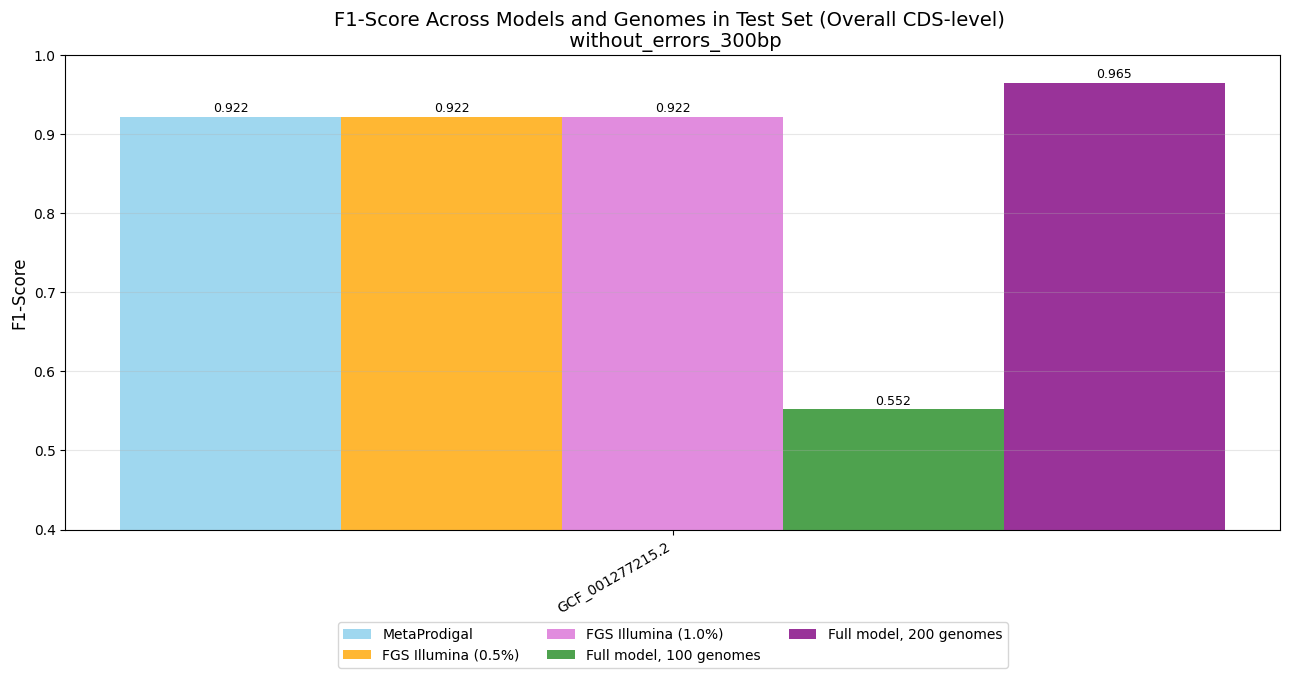

In [695]:
for data_type in data_types:

    #Initialize
    performance_metrics_genomes_dict = {}
    overlap_criteria = 1 #Overlap required to be considered a TP

    for test_accession in test_accessions:
        read_names_list, testset_dict, prodigal_dict, \
        preds_fgs_illumina_5_dict, preds_fgs_illumina_10_dict, \
        preds_model_8M_nt_shared_dict, preds_model_8M_nt_dict  = load_in_processed_datasets(test_accession, data_type)

        #Store performance metrics for this genome
        performance_metrics_genomes_dict[test_accession] = {
            "prodigal": calculate_metrics(testset_dict, prodigal_dict, read_names_list, overlap_criteria),
            "fgs_illumina_0.5%": calculate_metrics(testset_dict, preds_fgs_illumina_5_dict, read_names_list, overlap_criteria),
            "fgs_illumina_1.0%": calculate_metrics(testset_dict, preds_fgs_illumina_10_dict, read_names_list, overlap_criteria),
            "model_8m_nt_shared": calculate_metrics(testset_dict, preds_model_8M_nt_shared_dict, read_names_list, overlap_criteria),
            "model_8m_nt": calculate_metrics(testset_dict, preds_model_8M_nt_dict, read_names_list, overlap_criteria)}
        
    plot_all_models_comparison('f1_score', performance_metrics_genomes_dict, data_type)


    


In [696]:
#plot_all_models_comparison('precision', performance_metrics_genomes_dict)

In [697]:
#plot_all_models_comparison('recall', performance_metrics_genomes_dict)

# No errors in data